# One dimensional dummy problem

In this section the goal will be to solve the 1 dimensional dummy problem for a first step to pressure gradients

\begin{equation}
\begin{aligned}
\rho \partial_t v &=-RT\partial_x\rho-\rho v \partial_x v+\mu\partial_x^2 v \\
\partial_t\rho&=-(\partial_x \rho)v-\rho (\partial_x v)
\end{aligned}
\end{equation}

under IC:

\begin{equation}
\left\{ \begin{aligned}
\rho(x,0) &= 1 \\
v(x,0) &= 0
\end{aligned}\right.
\end{equation}

and BC:
\begin{equation}
\left\{\begin{aligned}
\rho(0,t) &= 2-e^{-10t} \\
\partial_x v(0,t) &= 0 \\
v(L,t) &= 0
\end{aligned}\right.
\end{equation}

In [1]:
using OrdinaryDiffEq, MethodOfLines, DomainSets, ModelingToolkit;

## Definitions

In [2]:
# Parameters, variables, and derivatives
@parameters t x
@variables ρ(..) v(..)

# definitions of derivatives
Dt = Differential(t)
Dx = Differential(x)
Dxx = Differential(x)^2

# constants
R = 1.0
T = 1.0
μ = 1.0

# PDE
eq = [
    ρ(t, x)*Dt(v(t, x)) ~ (-R*T*Dx(ρ(t, x))+μ*Dxx(v(t, x))-ρ(t, x)*v(t, x)*Dx(v(t, x))),
    Dt(ρ(t, x)) ~ -Dx(ρ(t, x))*v(t, x)-ρ(t, x)*Dx(v(t, x))
]

# Boundary conditions
bcs = [
    ρ(0, x) ~ 1.0,
    v(0, x) ~ 0.0,
    ρ(t,0) ~ 2.0 -exp(-10.0*t),
    Dx(v(t, 0)) ~ 0.0,
    v(t, 1) ~ 0.0
]

# Space and time domains
domains = [
    t ∈ Interval(0.0, 8.0),
    x ∈ Interval(0.0, 1.0)
]

2-element Vector{Symbolics.VarDomainPairing}:
 Symbolics.VarDomainPairing(t, 0.0 .. 8.0)
 Symbolics.VarDomainPairing(x, 0.0 .. 1.0)

## PDE

In [20]:
# PDE system
@named pdesys = PDESystem(
    eq, 
    bcs, 
    domains, 
    [t, x], [ρ(t, x), v(t, x)]
)

PDESystem
Equations: Equation[Differential(t, 1)(v(t, x)) ~ (Differential(x, 2)(v(t, x)) - Differential(x, 1)(ρ(t, x)) - ρ(t, x)*v(t, x)*Differential(x, 1)(v(t, x))) / ρ(t, x), Differential(t, 1)(ρ(t, x)) ~ -ρ(t, x)*Differential(x, 1)(v(t, x)) - Differential(x, 1)(ρ(t, x))*v(t, x)]
Boundary Conditions: Equation[ρ(0, x) ~ 1.0, v(0, x) ~ 0.0, ρ(t, 0) ~ 2.0 - exp(-10.0t), Differential(x, 1)(v(t, 0)) ~ 0.0, v(t, 1) ~ 0.0]
Domain: Symbolics.VarDomainPairing[Symbolics.VarDomainPairing(t, 0.0 .. 8.0), Symbolics.VarDomainPairing(x, 0.0 .. 1.0)]
Dependent Variables: Num[ρ(t, x), v(t, x)]
Independent Variables: Num[t, x]
Parameters: SciMLBase.NullParameters()
Default Parameter ValuesModelingToolkitBase.AtomicArrayDict{SymbolicUtils.BasicSymbolicImpl.var"typeof(BasicSymbolicImpl)"{SymReal}, Dict{SymbolicUtils.BasicSymbolicImpl.var"typeof(BasicSymbolicImpl)"{SymReal}, SymbolicUtils.BasicSymbolicImpl.var"typeof(BasicSymbolicImpl)"{SymReal}}}()

In [21]:
# Method of lines discretization
dx = .02
order = 2
discretization = MOLFiniteDifference([x => dx], t)

# Convert the PDE problem into an ODE problem
prob = discretize(pdesys, discretization);

# Solver

In [22]:
using OrdinaryDiffEq

In [28]:
# Solve ODE problem
sol = solve(prob, Tsit5(), saveat = 0.1)

"\\begin{align}\n\\frac{ - \\frac{\\mathrm{d}^{2}}{\\mathrm{d}x^{2}} ~ v\\left( t, x \\right) + \\frac{\\mathrm{d}}{\\mathrm{d}x} ~ \\rho\\left( t, x \\right) + \\rho\\left( t, x \\right) ~ v\\left( t, x \\right) ~ \\frac{\\mathrm{d}}{\\mathrm{d}x} ~ v\\left( t, x \\right)}{\\rho\\left( t, x \\right" ⋯ 32 bytes ⋯ "}t} ~ v\\left( t, x \\right) &= 0 \\\\\n\\frac{\\mathrm{d}}{\\mathrm{d}t} ~ \\rho\\left( t, x \\right) + \\rho\\left( t, x \\right) ~ \\frac{\\mathrm{d}}{\\mathrm{d}x} ~ v\\left( t, x \\right) + \\frac{\\mathrm{d}}{\\mathrm{d}x} ~ \\rho\\left( t, x \\right) ~ v\\left( t, x \\right) &= 0\n\\end{align}\n"

L"\begin{align}
\rho\left( 0, x \right) &= 1 \\
v\left( 0, x \right) &= 0 \\
\rho\left( t, 0 \right) &= 2 - e^{ - 10 ~ t} \\
\frac{\mathrm{d}}{\mathrm{d}x} ~ v\left( t, 0 \right) &= 0 \\
v\left( t, 1 \right) &= 0
\end{align}
"

PDESolution:
  Return Code:
    Success
  Dependent variables:
    v(t, x): (81, 51) sized solution
    ρ(t, x): (81, 51) sized solution
  Domain:
    t ∈ (0.0, 8.0) with 81 points, step size 0.1
    x ∈ (0.0, 1.0) with 51 points, step size 0.02
  From system:
    Equations:
    Boundary/Initial Conditions:


In [38]:
sol.retcode
length(sol.t)
sol.t[end]
minimum(sol_ρ)

1.0

In [29]:
sol.stats

SciMLBase.DEStats
Number of function 1 evaluations:                  74283
Number of function 2 evaluations:                  0
Number of W matrix evaluations:                    0
Number of linear solves:                           0
Number of Jacobians created:                       0
Number of nonlinear solver iterations:             0
Number of nonlinear solver convergence failures:   0
Number of fixed-point solver iterations:           0
Number of fixed-point solver convergence failures: 0
Number of rootfind condition calls:                0
Number of accepted steps:                          12379
Number of rejected steps:                          1

## Plotting/animating

In [30]:
# Plot results and compare with exact solution
discrete_x = sol[x];
discrete_t = sol[t];
sol_ρ = sol[ρ(t, x)];
sol_v = sol[v(t, x)];


folder = "e. one dimensional FD with advection";
mkpath(folder);

In [31]:
# Used for plotting
using Plots

┌ Info: Saved animation to c:\Users\noudh\uni\MEP\3. rho time derivative\e. one dimensional FD with advection\ρ.gif
└ @ Plots C:\Users\noudh\.julia\packages\Plots\GIume\src\animation.jl:156


Plots.AnimatedGif("c:\\Users\\noudh\\uni\\MEP\\3. rho time derivative\\e. one dimensional FD with advection\\ρ.gif")
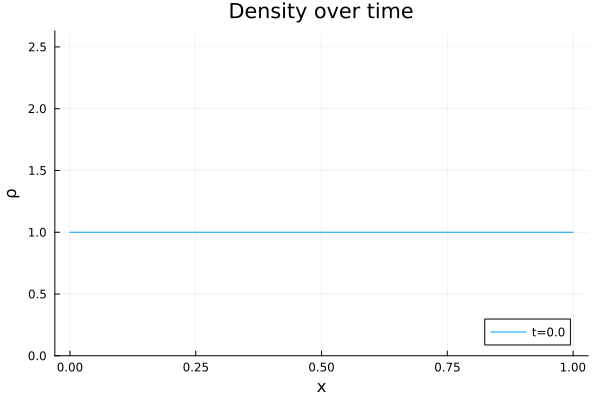

In [35]:
ymin = 0
ymax = maximum(sol_ρ)

anim = @animate for k in 1:length(discrete_t)
    plot(
        discrete_x, 
        sol_ρ[k, :], 
        title = "Density over time", 
        ylims = (ymin, ymax), 
        ylabel = "ρ",
        xlabel = "x",
        label = "t=$(discrete_t[k])",
        legend = :bottomright
    )
end

gif(anim, joinpath(folder, "ρ.gif"), fps = 10)

┌ Info: Saved animation to c:\Users\noudh\uni\MEP\3. rho time derivative\e. one dimensional FD with advection\v.gif
└ @ Plots C:\Users\noudh\.julia\packages\Plots\GIume\src\animation.jl:156


Plots.AnimatedGif("c:\\Users\\noudh\\uni\\MEP\\3. rho time derivative\\e. one dimensional FD with advection\\v.gif")
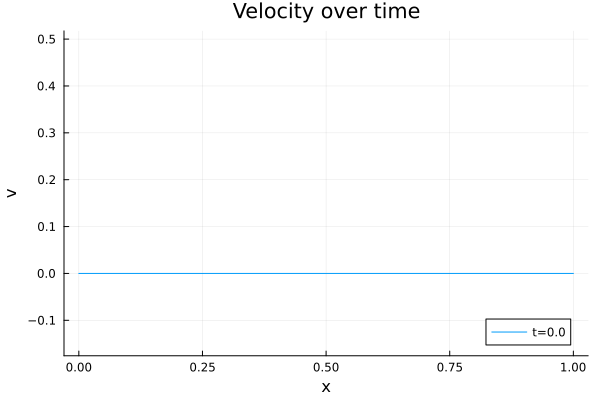

In [34]:
ymin = minimum(sol_v)
ymax = maximum(sol_v)

anim = @animate for k in 1:length(discrete_t)
    plot(
        discrete_x, 
        sol_v[k, :], 
        title = "Velocity over time", 
        ylims = (ymin, ymax), 
        ylabel = "v",
        xlabel = "x",
        label = "t=$(discrete_t[k])",
        legend = :bottomright
    )
end

gif(anim, joinpath(folder, "v.gif"), fps = 10)

┌ Info: Saved animation to c:\Users\noudh\uni\MEP\3. rho time derivative\e. one dimensional FD with advection\flow.gif
└ @ Plots C:\Users\noudh\.julia\packages\Plots\GIume\src\animation.jl:156


Plots.AnimatedGif("c:\\Users\\noudh\\uni\\MEP\\3. rho time derivative\\e. one dimensional FD with advection\\flow.gif")
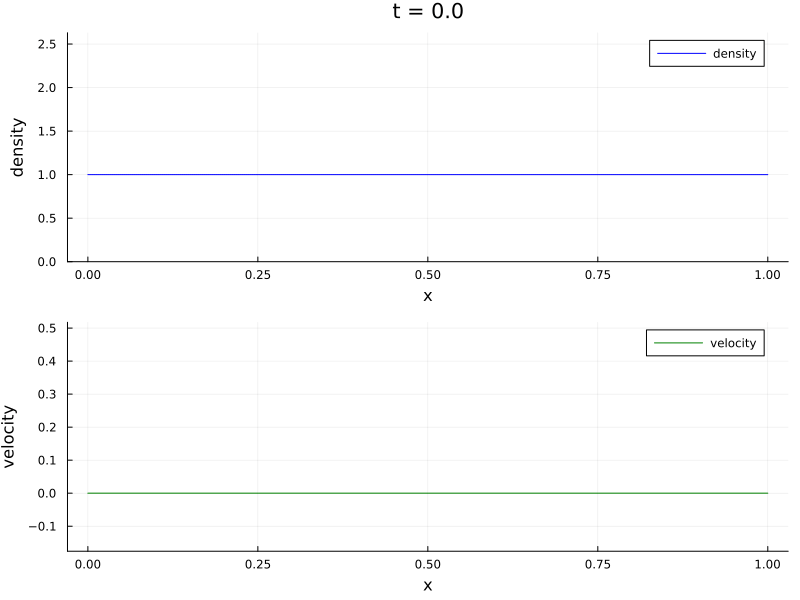

In [39]:
# limits
ρmin = minimum(sol_ρ)
ρmax = maximum(sol_ρ)

vmin = minimum(sol_v)
vmax = maximum(sol_v)

left_min = ρmin
left_max = ρmax

anim = @animate for k in 1:length(discrete_t)

    # top plot: density + total pressure
    p1 = plot(
        discrete_x,
        sol_ρ[k, :],

        label = "density",
        color = :blue,

        xlabel = "x",
        ylabel = "density",
        title = "t = $(round(discrete_t[k], digits=3))",

        ylims = (0, ρmax),

        legend = :topright)
    

    # bottom plot: velocity
    p2 = plot(
        discrete_x,
        sol_v[k, :],

        label = "velocity",
        color = :green,

        xlabel = "x",
        ylabel = "velocity",

        ylims = (vmin, vmax),

        legend = :topright
    )

    # combine vertically
    plot(
        p1,
        p2,

        layout = (2,1),
        size = (800,600)
    )

end

gif(anim, joinpath(folder, "flow.gif"), fps = 10)

### Ugly plots below

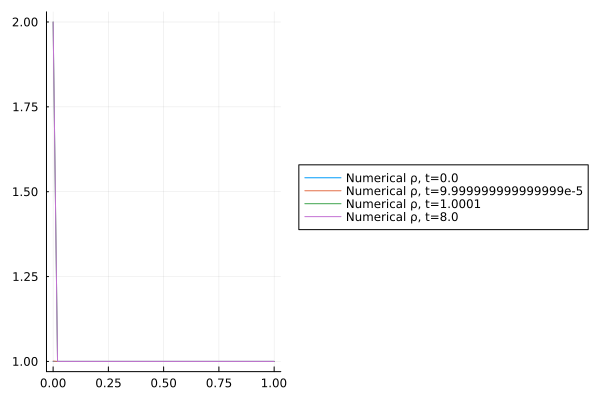

In [12]:
plt = plot(legend = :outerright)
for i in eachindex(discrete_t)
    plot!(discrete_x, sol_ρ[i, :], label = "Numerical ρ, t=$(discrete_t[i])")
end
plt

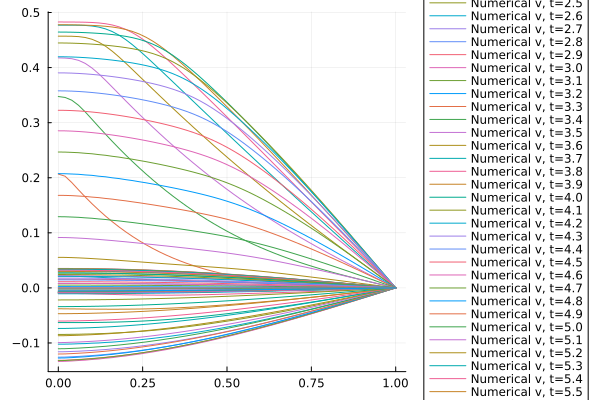

In [15]:
plt = plot(legend = :outerright)
for i in eachindex(discrete_t)
    plot!(discrete_x, sol_v[i, :], label = "Numerical v, t=$(discrete_t[i])")
end
plt